### Investigate effect of the loss function

##### 1. Reproduce example presented during the lecture (trade signal)

data shape: (100, 3) 
    Unnamed: 0         X         Y
0           0 -0.015981  0.001984


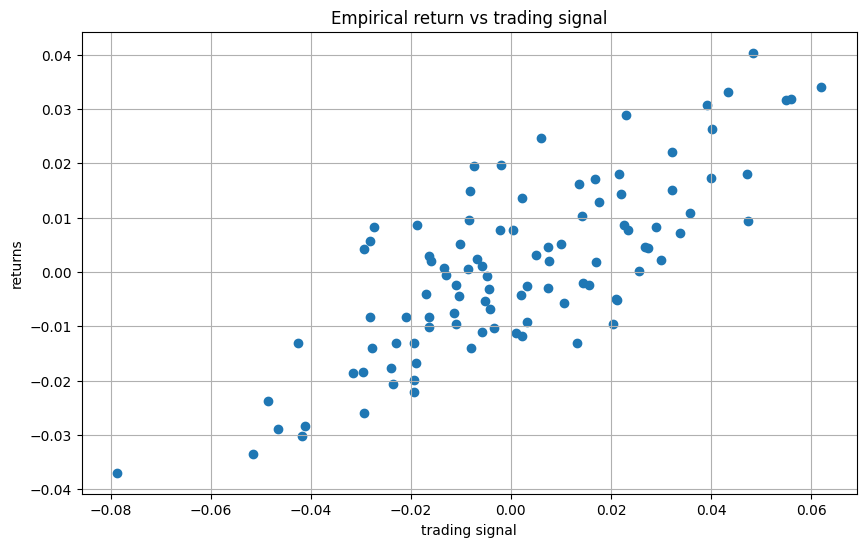

Linear regression result: Y = 0.4688 * X + 0.0002


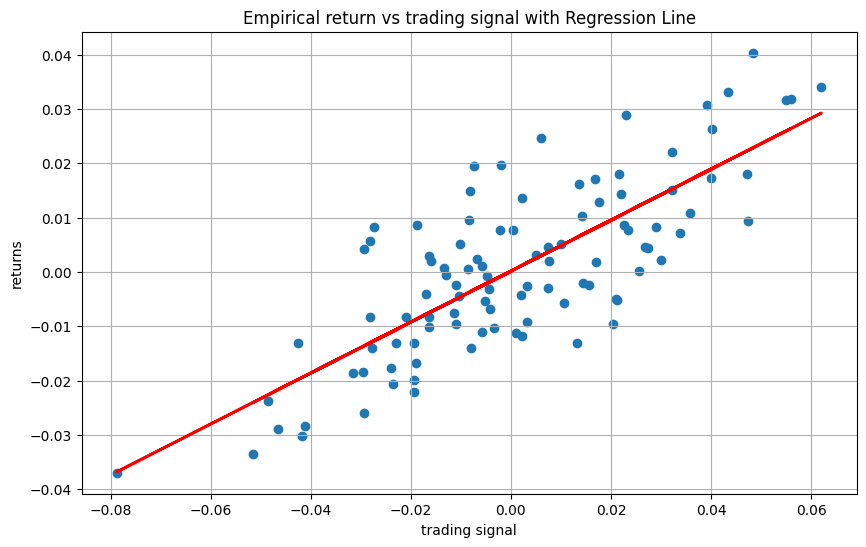

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

data = pd.read_excel('data_9.xlsx')

print("data shape:", data.shape, '\n', data.head(1))

data = data.iloc[:, -2:]

plt.figure(figsize=(10, 6))
plt.scatter(data['X'], data['Y'])
plt.title('Empirical return vs trading signal')
plt.xlabel('trading signal')    
plt.ylabel('returns')
plt.grid(True)
plt.show()

reg = LinearRegression().fit(data[['X']], data['Y'])
a = reg.coef_[0]
b = reg.intercept_

print(f"Linear regression result: Y = {a:.4f} * X + {b:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(data['X'], data['Y'])
plt.plot(data['X'], reg.predict(data[['X']]), color='red', linewidth=2)
plt.title('Empirical return vs trading signal with Regression Line')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.grid(True)
plt.show()



##### 2. Check what happens when:


In [ ]:
import pymc as pm  
from scipy.optimize import fmin

X = data['X']
Y = data['Y']
np.random.seed(42)

class tradePredictions:
    def __init__(self, X, Y):
        self._X = X
        self._Y = Y
        with pm.Model() as model:
            std = pm.Uniform("std", 0, 100)
            beta = pm.Normal("beta", mu=0, sigma=100)
            alpha = pm.Normal("alpha", mu=0, sigma=100)
            mean = pm.Deterministic("mean", alpha + beta * X.ravel())
            obs = pm.Normal("obs", mu=mean, sigma=std, observed=Y)
    
            self._idata = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42)

    def stock_loss(factual, predicted, coef = 100.):
        if factual * predicted < 0:
            return coef * predicted**2 + abs(factual - predicted)
        else:
            return abs(factual - predicted)

    def stock_loss_vect(self, factual_vect, predicted, coef=100):
        loss_vect = np.zeros_like(factual_vect)
        ix_vect = factual_vect * predicted < 0
        loss_vect[ix_vect] = coef * predicted ** 2 + abs(factual_vect[ix_vect] - predicted)
        loss_vect[~ix_vect] = abs(factual_vect[~ix_vect] - predicted)
        return loss_vect.mean()

    def calculate_line(self, coef=100):
        std_samples = self._idata.posterior["std"].values.flatten()
        alpha_samples = self._idata.posterior["alpha"].values.flatten()
        beta_samples = self._idata.posterior["beta"].values.flatten()
        N = std_samples.shape[0]
        
        opt_predictions = np.zeros(50)
        trade_signals = np.linspace(self._X.min(), self._X.max(), 50)
        for i, signal in enumerate(trade_signals):
            noise = std_samples * np.random.randn(N)

            possible_outcomes = alpha_samples + beta_samples * signal + noise
            def tomin(pred):
                return self.stock_loss_vect(possible_outcomes, pred, coef)
            opt_predictions[i] = fmin(tomin, 0, disp=False)

        return trade_signals, opt_predictions

model = tradePredictions(X, Y)

C:\Users\Filip\AppData\Local\Temp\ipykernel_15052\4029210293.py:17: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  mean = pm.Deterministic("mean", alpha + beta * X.ravel())
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [std, beta, alpha]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.


 - The quadratic part of the loss function is disabled

C:\Users\Filip\AppData\Local\Temp\ipykernel_15052\4029210293.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


[-0.036875  -0.035375  -0.0341875 -0.03275   -0.0315625 -0.0299375
 -0.028625  -0.02725   -0.0259375 -0.0245625 -0.0231875 -0.021875
 -0.02075   -0.0190625 -0.0176875 -0.0168125 -0.0150625 -0.0139375
 -0.0123125 -0.01125   -0.0098125 -0.0084375 -0.0070625 -0.0058125
 -0.0044375 -0.003125  -0.001625  -0.000375   0.001      0.00225
  0.0035     0.0049375  0.0063125  0.0075625  0.009      0.010625
  0.0115625  0.0129375  0.014375   0.015625   0.0171875  0.0186875
  0.019625   0.0211875  0.0225625  0.024125   0.025375   0.0265
  0.027875   0.0290625]


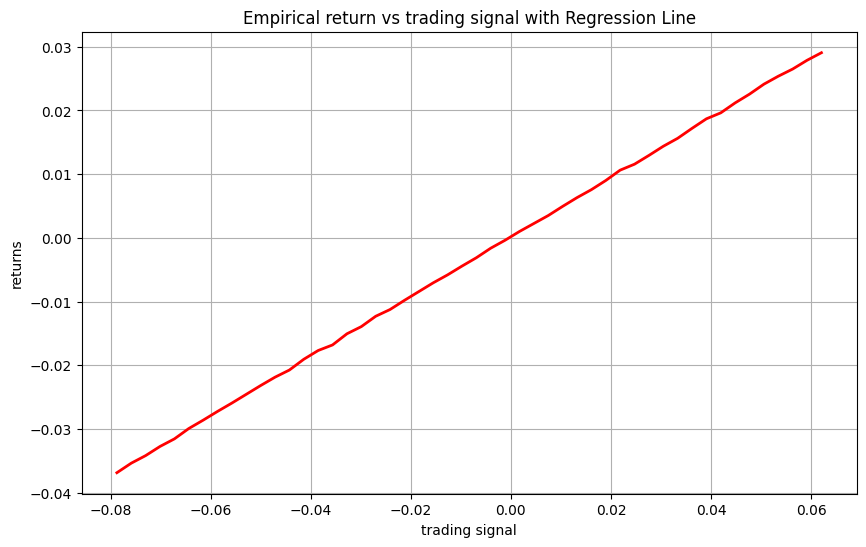

In [24]:
x, res0 = model.calculate_line(0)

print(res0)

plt.figure(figsize=(10, 6))
plt.plot(x, res0, color='red', linewidth=2)
plt.title('Empirical return vs trading signal with Regression Line')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.grid(True)
plt.show()

- The coefficient by which the quadratic part is multiplied is changed to:
    - 500

C:\Users\Filip\AppData\Local\Temp\ipykernel_15052\4029210293.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


[-3.67500e-02 -3.54375e-02 -3.33125e-02 -3.20625e-02 -3.08750e-02
 -2.91875e-02 -2.78125e-02 -2.60000e-02 -2.39375e-02 -2.27500e-02
 -1.98750e-02 -1.78125e-02 -1.56250e-02 -1.34375e-02 -1.15625e-02
 -1.00625e-02 -8.00000e-03 -6.12500e-03 -4.75000e-03 -3.81250e-03
 -2.87500e-03 -2.31250e-03 -1.75000e-03 -1.25000e-03 -8.12500e-04
 -5.00000e-04 -2.50000e-04 -6.25000e-05  1.87500e-04  3.75000e-04
  6.25000e-04  1.06250e-03  1.43750e-03  1.87500e-03  2.56250e-03
  3.37500e-03  4.12500e-03  5.93750e-03  6.87500e-03  8.81250e-03
  1.01875e-02  1.20000e-02  1.44375e-02  1.66250e-02  1.88125e-02
  2.09375e-02  2.25625e-02  2.45625e-02  2.66875e-02  2.81875e-02]


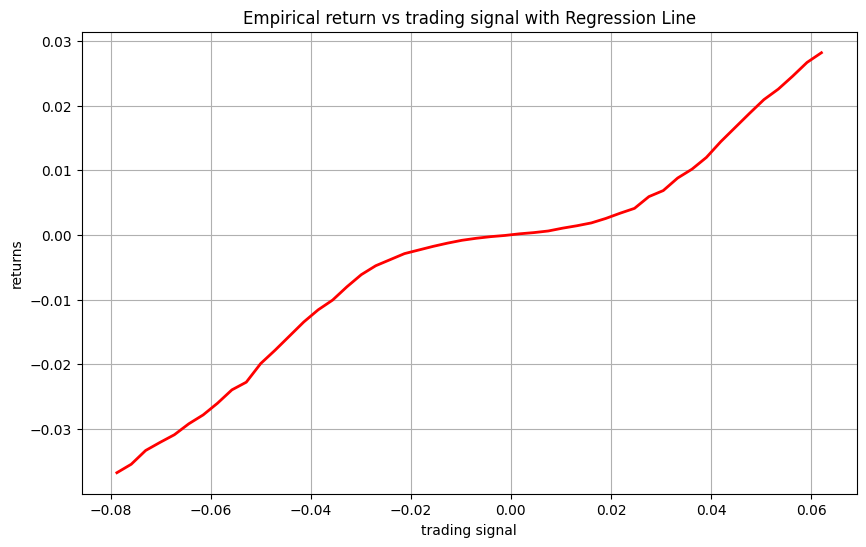

In [25]:
x, res500 = model.calculate_line(500)

print(res500)

plt.figure(figsize=(10, 6))
plt.plot(x, res500, color='red', linewidth=2)
plt.title('Empirical return vs trading signal with Regression Line')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.grid(True)
plt.show()

- 
    - 1000

C:\Users\Filip\AppData\Local\Temp\ipykernel_15052\4029210293.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


[-3.66250e-02 -3.52500e-02 -3.34375e-02 -3.18750e-02 -3.06875e-02
 -2.81250e-02 -2.63125e-02 -2.42500e-02 -2.21250e-02 -1.97500e-02
 -1.79375e-02 -1.48750e-02 -1.17500e-02 -1.02500e-02 -8.00000e-03
 -6.37500e-03 -5.06250e-03 -4.06250e-03 -3.00000e-03 -2.37500e-03
 -1.68750e-03 -1.37500e-03 -1.00000e-03 -6.87500e-04 -5.00000e-04
 -2.50000e-04 -1.87500e-04  0.00000e+00  6.25000e-05  1.87500e-04
  3.75000e-04  5.62500e-04  8.12500e-04  1.06250e-03  1.43750e-03
  2.00000e-03  2.31250e-03  3.25000e-03  4.25000e-03  5.31250e-03
  6.87500e-03  8.62500e-03  1.05625e-02  1.33125e-02  1.60000e-02
  1.85625e-02  2.11250e-02  2.24375e-02  2.49375e-02  2.81250e-02]


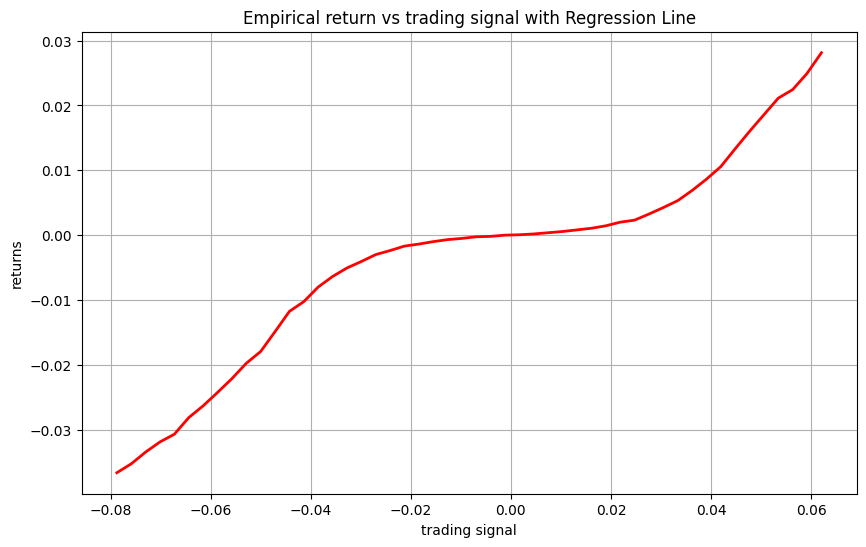

In [26]:
x, res1000 = model.calculate_line(1000)

print(res1000)

plt.figure(figsize=(10, 6))
plt.plot(x, res1000, color='red', linewidth=2)
plt.title('Empirical return vs trading signal with Regression Line')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.grid(True)
plt.show()

C:\Users\Filip\AppData\Local\Temp\ipykernel_15052\853129489.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  plt.scatter(X.ravel(), Y, alpha=0.5, s=60, edgecolors='black', linewidth=0.5, zorder=1)


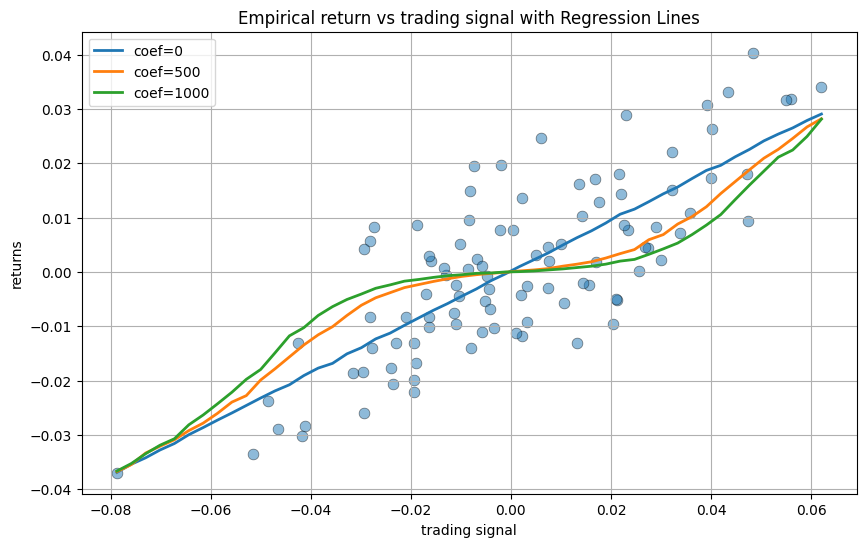

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(x, res0, label='coef=0', linewidth=2)
plt.plot(x, res500, label='coef=500', linewidth=2)
plt.plot(x, res1000, label='coef=1000', linewidth=2)
plt.scatter(X.ravel(), Y, alpha=0.5, s=60, edgecolors='black', linewidth=0.5, zorder=1)
plt.title('Empirical return vs trading signal with Regression Lines')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.legend()
plt.grid(True) 
plt.show()